In [11]:
import os
import logging
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime


In [12]:
df = pd.read_csv("products.csv")
df.head()

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [15]:
# ─────────────────────────────────────────────
# BƯỚC 1: LOAD
# Đọc toàn bộ CSV vào một dictionary {tên: DataFrame}
# ─────────────────────────────────────────────
 
FILES = {
    "products":    "products.csv",
    "customers":   "customers.csv",
    "promotions":  "promotions.csv",
    "geography":   "geography.csv",
    "orders":      "orders.csv",
    "order_items": "order_items.csv",
    "payments":    "payments.csv",
    "shipments":   "shipments.csv",
    "returns":     "returns.csv",
    "reviews":     "reviews.csv",
    "sales":       "sales.csv",
    "inventory":   "inventory.csv",
    "web_traffic": "web_traffic.csv",
}
 
def step1_load(data_dir: Path) -> dict[str, pd.DataFrame]:
    """Đọc tất cả file CSV."""
    print("=" * 60)
    print("BƯỚC 1: LOAD")
    print("=" * 60)
 
    tables = {}
    for name, filename in FILES.items():
        path = data_dir / filename
        if not path.exists():
            print(f"  Không tìm thấy file: {filename} -> bỏ qua")
            continue
        df = pd.read_csv(path, low_memory=False)
        tables[name] = df
        print(f"  [OK] {filename:30s}  {df.shape[0]:>7,} dòng  x  {df.shape[1]:>2} cột")
 
    print(f"  -> Đã load {len(tables)}/{len(FILES)} bảng\n")
    return tables

In [30]:
# ─────────────────────────────────────────────
# BƯỚC 2: VALIDATE
# Kiểm tra null, duplicate, dtype, ràng buộc nghiệp vụ
# ─────────────────────────────────────────────
 
# Các cột nullable theo thiết kế (không cảnh báo nếu null)
NULLABLE_COLUMNS = {
    "customers":   ["gender", "age_group", "acquisition_channel"],
    "promotions":  ["applicable_category", "promo_channel", "min_order_value"],
    "order_items": ["promo_id", "promo_id_2"],
}
 
# Các cột phải là kiểu datetime
DATE_COLUMNS = {
    "orders":      ["order_date"],
    "customers":   ["signup_date"],
    "promotions":  ["start_date", "end_date"],
    "shipments":   ["ship_date", "delivery_date"],
    "returns":     ["return_date"],
    "reviews":     ["review_date"],
    "inventory":   ["snapshot_date"],
    "web_traffic": ["date"],
    "sales":       ["Date"],
}
 
def step2_validate(tables: dict) -> dict:
    """Kiểm tra chất lượng dữ liệu và tạo báo cáo QA."""
    print("=" * 60)
    print("BƯỚC 2: VALIDATE")
    print("=" * 60)
 
    qa_report = {}
 
    for name, df in tables.items():
        issues = []
        nullable = NULLABLE_COLUMNS.get(name, [])
 
        # --- 2a. Kiểm tra null ---
        null_counts = df.isnull().sum()
        for col, cnt in null_counts[null_counts > 0].items():
            pct = cnt / len(df) * 100
            if col not in nullable:
                issues.append(f"NULL  {col}: {cnt:,} dòng ({pct:.1f}%)")
            # nullable columns -> chỉ log ở debug level
            else:
                print(f"  [{name}] {col}: {cnt} null (nullable - bình thường)")
 
        # --- 2b. Kiểm tra duplicate ---
        dup = df.duplicated().sum()
        if dup > 0:
            issues.append(f"DUPLICATE: {dup:,} dòng trùng")
 
        # --- 2c. Kiểm tra kiểu dữ liệu ngày ---
        date_cols = DATE_COLUMNS.get(name, [])
        for col in date_cols:
            if col in df.columns and df[col].dtype == object:
                issues.append(f"DTYPE  {col}: vẫn là string, cần convert sang datetime")
 
        # --- 2d. Ràng buộc nghiệp vụ ---
        if name == "products" and "cogs" in df.columns and "price" in df.columns:
            bad = (df["cogs"] >= df["price"]).sum()
            if bad > 0:
                issues.append(f"CONSTRAINT  cogs >= price: {bad:,} sản phẩm vi phạm")
 
        if name == "reviews" and "rating" in df.columns:
            bad = (~df["rating"].between(1, 5)).sum()
            if bad > 0:
                issues.append(f"CONSTRAINT  rating ngoài [1,5]: {bad:,} dòng")
 
        qa_report[name] = issues
        status = "[OK] OK" if not issues else f"[!!] {len(issues)} vấn đề"
        print(f"  [{name}]  {status}")
        for issue in issues:
            print(f"      -> {issue}")
 
    print("")
    return qa_report

In [31]:
# ─────────────────────────────────────────────
# BƯỚC 3: CLEAN & CAST
# Fix dtype, điền null, tạo derived columns
# ─────────────────────────────────────────────
 
def step3_clean(tables: dict) -> dict:
    """Làm sạch và chuẩn hóa dữ liệu."""
    print("=" * 60)
    print("BƯỚC 3: CLEAN & CAST")
    print("=" * 60)
 
    # --- 3a. Convert cột ngày sang datetime ---
    for table_name, cols in DATE_COLUMNS.items():
        if table_name not in tables:
            continue
        df = tables[table_name]
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
                print(f"  [OK] [{table_name}] {col} -> datetime")
        tables[table_name] = df
 
    # --- 3b. Chuẩn hóa cột string (strip whitespace, lowercase key columns) ---
    str_cols_lower = {
        "products":  ["category", "segment"],
        "customers": ["gender", "age_group", "acquisition_channel"],
        "orders":    ["order_status", "payment_method", "order_source"],
    }
    for table_name, cols in str_cols_lower.items():
        if table_name not in tables:
            continue
        df = tables[table_name]
        for col in cols:
            if col in df.columns and df[col].dtype == object:
                df[col] = df[col].str.strip().str.lower()
        tables[table_name] = df
        print(f"  [OK] [{table_name}] chuẩn hóa string columns")
 
    # --- 3c. Fix kiểu số ---
    num_cols = {
        "products":    ["price", "cogs"],
        "order_items": ["unit_price", "discount_amount"],
        "payments":    ["payment_value"],
        "shipments":   ["shipping_fee"],
        "returns":     ["refund_amount"],
        "promotions":  ["discount_value", "min_order_value"],
    }
    for table_name, cols in num_cols.items():
        if table_name not in tables:
            continue
        df = tables[table_name]
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        tables[table_name] = df
        print(f"  [OK] [{table_name}] numeric columns fixed")
 
    # --- 3d. Tạo Derived Columns ---
 
    # orders: thêm năm, tháng, quý
    if "orders" in tables:
        df = tables["orders"]
        if "order_date" in df.columns:
            df["order_year"]    = df["order_date"].dt.year
            df["order_month"]   = df["order_date"].dt.month
            df["order_quarter"] = df["order_date"].dt.quarter
        tables["orders"] = df
        print("  [OK] [orders] thêm year, month, quarter")
 
    # order_items: thêm revenue (trước giảm giá) và net_revenue
    if "order_items" in tables:
        df = tables["order_items"]
        if "unit_price" in df.columns and "quantity" in df.columns:
            df["gross_revenue"] = df["unit_price"] * df["quantity"]
            df["net_revenue"]   = df["gross_revenue"] - df.get("discount_amount", 0)
        tables["order_items"] = df
        print("  [OK] [order_items] thêm gross_revenue, net_revenue")
 
    # products: thêm gross_margin
    if "products" in tables:
        df = tables["products"]
        if "price" in df.columns and "cogs" in df.columns:
            df["gross_margin"] = (df["price"] - df["cogs"]) / df["price"]
        tables["products"] = df
        print("  [OK] [products] thêm gross_margin")
 
    # customers: thêm tenure_days (kể từ ngày đăng ký)
    if "customers" in tables:
        df = tables["customers"]
        if "signup_date" in df.columns:
            today = pd.Timestamp.today()
            df["tenure_days"] = (today - df["signup_date"]).dt.days
        tables["customers"] = df
        print("  [OK] [customers] thêm tenure_days")
 
    print("")
    return tables

In [32]:
# ─────────────────────────────────────────────
# BƯỚC 4: JOIN & EXPORT
# Tạo các master DataFrame phục vụ visualize
# ─────────────────────────────────────────────
 
def step4_join_and_export(tables: dict, output_dir: Path):
    """Tạo master tables và xuất file."""
    print("=" * 60)
    print("BƯỚC 4: JOIN & EXPORT")
    print("=" * 60)
 
    results = {}
 
    # ── 4a. orders_master ──────────────────────────────────────
    # orders ← customers ← geography ← payments ← shipments
    if all(k in tables for k in ["orders", "customers", "geography"]):
        orders_master = tables["orders"].copy()
 
        # Join customers
        orders_master = orders_master.merge(
            tables["customers"].add_prefix("cust_").rename(columns={"cust_customer_id": "customer_id"}),
            on="customer_id", how="left"
        )
 
        # Join geography (theo zip của đơn hàng)
        orders_master = orders_master.merge(
            tables["geography"].add_prefix("geo_").rename(columns={"geo_zip": "zip"}),
            on="zip", how="left"
        )
 
        # Join payments (1:1)
        if "payments" in tables:
            orders_master = orders_master.merge(
                tables["payments"][["order_id", "payment_method", "payment_value", "installments"]],
                on="order_id", how="left"
            )
 
        # Join shipments
        if "shipments" in tables:
            orders_master = orders_master.merge(
                tables["shipments"][["order_id", "ship_date", "delivery_date", "shipping_fee"]],
                on="order_id", how="left"
            )
            orders_master["delivery_days"] = (
                orders_master["delivery_date"] - orders_master["ship_date"]
            ).dt.days
 
        results["orders_master"] = orders_master
        print(f"  [OK] orders_master: {orders_master.shape}")
 
    # ── 4b. order_items_master ─────────────────────────────────
    # order_items ← products ← orders(date info) ← promotions
    if all(k in tables for k in ["order_items", "products", "orders"]):
        items = tables["order_items"].copy()
 
        # Join products
        items = items.merge(
            tables["products"][["product_id", "product_name", "category", "segment",
                                "size", "color", "price", "cogs", "gross_margin"]],
            on="product_id", how="left"
        )
 
        # Join order date
        items = items.merge(
            tables["orders"][["order_id", "order_date", "order_year",
                              "order_month", "order_quarter", "order_status", "customer_id"]],
            on="order_id", how="left"
        )
 
        # Join promotions (promo_id - khuyến mãi chính)
        if "promotions" in tables:
            promo_cols = ["promo_id", "promo_name", "promo_type",
                          "discount_value", "promo_channel", "stackable_flag"]
            promo_cols = [c for c in promo_cols if c in tables["promotions"].columns]
            items = items.merge(
                tables["promotions"][promo_cols],
                on="promo_id", how="left"
            )
            # Thêm flag: đơn có hay không có khuyến mãi
            items["has_promo"] = items["promo_id"].notna().astype(int)
            print(f"  [OK] [order_items_master] join promotions (promo_id)")
 
            # Join promotions lần 2 (promo_id_2 - khuyến mãi thứ hai)
            if "promo_id_2" in items.columns:
                promo2_rename = {c: c + "_2" for c in promo_cols if c != "promo_id"}
                promo2_rename["promo_id"] = "promo_id_2"
                items = items.merge(
                    tables["promotions"][promo_cols].rename(columns=promo2_rename),
                    on="promo_id_2", how="left"
                )
                # Flag: đơn dùng 2 khuyến mãi cùng lúc
                items["has_promo_2"] = items["promo_id_2"].notna().astype(int)
                print(f"  [OK] [order_items_master] join promotions (promo_id_2)")
 
        # Thêm cột lợi nhuận
        if "cogs" in items.columns and "quantity" in items.columns:
            items["cogs_total"]        = items["cogs"] * items["quantity"]
            items["gross_profit"]      = items["net_revenue"] - items["cogs_total"]
            # True margin sau khuyến mãi
            items["true_gross_margin"] = (
                items["gross_profit"] / items["gross_revenue"].replace(0, float("nan"))
            )
 
        results["order_items_master"] = items
        print(f"  [OK] order_items_master: {items.shape}")
 
    # ── 4c. returns_master ─────────────────────────────────────
    if all(k in tables for k in ["returns", "orders", "products"]):
        ret = tables["returns"].copy()
        ret = ret.merge(
            tables["orders"][["order_id", "customer_id", "order_date"]],
            on="order_id", how="left"
        )
        ret = ret.merge(
            tables["products"][["product_id", "product_name", "category"]],
            on="product_id", how="left"
        )
        results["returns_master"] = ret
        print(f"  [OK] returns_master: {ret.shape}")
 
    # ── 4d. Xuất file ──────────────────────────────────────────
    for table_name, df in results.items():
        # Xuất CSV
        csv_path = output_dir / f"{table_name}.csv"
        df.to_csv(csv_path, index=False)
        print(f"  -> Saved: {csv_path}")
 
        # Xuất Parquet (nhỏ hơn, đọc nhanh hơn)
        try:
            parquet_path = output_dir / f"{table_name}.parquet"
            df.to_parquet(parquet_path, index=False)
            print(f"  -> Saved: {parquet_path}")
        except ImportError:
            print("  Cần cài pyarrow để xuất Parquet: pip install pyarrow")
 
    # ── 4e. Xuất QA summary ────────────────────────────────────
    summary_rows = []
    for name, df in tables.items():
        summary_rows.append({
            "table":      name,
            "rows":       len(df),
            "cols":       len(df.columns),
            "null_cells": df.isnull().sum().sum(),
            "duplicates": df.duplicated().sum(),
        })
    summary_df = pd.DataFrame(summary_rows)
    summary_path = output_dir / "qa_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"\n  -> QA summary: {summary_path}")
 
    print("")
    return results

In [33]:
# ─────────────────────────────────────────────
# MAIN: Chạy toàn bộ pipeline
# ─────────────────────────────────────────────
 
def run_pipeline(data_dir: str = "."):
    start = datetime.now()
    print("=" * 60)
    print("       DATA PIPELINE - BAT DAU")
    print("=" * 60)
 
    data_path = Path(data_dir)
 
    tables    = step1_load(data_path)
    qa_report = step2_validate(tables)
    tables    = step3_clean(tables)
    results   = step4_join_and_export(tables, OUTPUT_DIR)
 
    elapsed = (datetime.now() - start).seconds
    print("=" * 60)
    print(f"  HOAN THANH  |  {elapsed}s  |  {len(results)} master tables")
    print("=" * 60)
 
    return tables, results

In [34]:
tables, results = run_pipeline(".")

       DATA PIPELINE - BAT DAU
BƯỚC 1: LOAD
  [OK] products.csv                      2,412 dòng  x   8 cột
  [OK] customers.csv                   121,930 dòng  x   7 cột
  [OK] promotions.csv                       50 dòng  x  10 cột
  [OK] geography.csv                    39,948 dòng  x   4 cột
  [OK] orders.csv                      646,945 dòng  x   8 cột
  [OK] order_items.csv                 714,669 dòng  x   7 cột
  [OK] payments.csv                    646,945 dòng  x   4 cột
  [OK] shipments.csv                   566,067 dòng  x   4 cột
  [OK] returns.csv                      39,939 dòng  x   7 cột
  [OK] reviews.csv                     113,551 dòng  x   7 cột
  [OK] sales.csv                         3,833 dòng  x   3 cột
  [OK] inventory.csv                    60,247 dòng  x  17 cột
  [OK] web_traffic.csv                   3,652 dòng  x   7 cột
  -> Đã load 13/13 bảng

BƯỚC 2: VALIDATE
  [products]  [OK] OK
  [customers]  [!!] 1 vấn đề
      -> DTYPE  signup_date: vẫn là string, 

NameError: name 'OUTPUT_DIR' is not defined

In [ ]:
orders_master      = results["orders_master"]
order_items_master = results["order_items_master"]
returns_master     = results["returns_master"]

In [ ]:
print(order_items_master.head())

In [21]:
!pip install plotly

In [22]:
!pip install nbformat --upgrade

In [24]:
"""
Chart: Gross Revenue & Gross Profit theo tháng
===============================================
Nguồn: order_items_master (output từ pipeline)
"""

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ──────────────────────────────────────────────
# 1. LOAD DỮ LIỆU
# ──────────────────────────────────────────────

df = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])

# ──────────────────────────────────────────────
# 2. CHUẨN BỊ DỮ LIỆU
# ──────────────────────────────────────────────

# Gom theo tháng
monthly = (
    df.groupby(df["order_date"].dt.to_period("M"))
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        gross_profit =("gross_profit",  "sum"),
    )
    .reset_index()
)
monthly["order_date"]   = monthly["order_date"].dt.to_timestamp()
monthly["gross_margin"] = monthly["gross_profit"] / monthly["gross_revenue"] * 100

# Rolling 3 tháng để smoothe đường trend
monthly["rev_ma3"]    = monthly["gross_revenue"].rolling(3, min_periods=1).mean()
monthly["profit_ma3"] = monthly["gross_profit"].rolling(3, min_periods=1).mean()

# ──────────────────────────────────────────────
# 3. VẼ BIỂU ĐỒ
# ──────────────────────────────────────────────

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.68, 0.32],
    vertical_spacing=0.06,
    subplot_titles=("Gross Revenue & Gross Profit theo tháng", "Gross Margin (%)")
)

# ── Panel trên: Revenue & Profit ──────────────

# Vùng revenue (area)
fig.add_trace(go.Scatter(
    x=monthly["order_date"], y=monthly["gross_revenue"],
    name="Gross Revenue",
    mode="lines",
    line=dict(color="#378ADD", width=1.5, dash="dot"),
    fill="tozeroy",
    fillcolor="rgba(55,138,221,0.07)",
    hovertemplate="%{x|%m/%Y}<br>Revenue: %{y:,.0f}<extra></extra>",
), row=1, col=1)

# MA-3 revenue
fig.add_trace(go.Scatter(
    x=monthly["order_date"], y=monthly["rev_ma3"],
    name="Revenue MA-3",
    mode="lines",
    line=dict(color="#378ADD", width=2.5),
    hovertemplate="Revenue MA-3: %{y:,.0f}<extra></extra>",
), row=1, col=1)

# Vùng profit (area)
fig.add_trace(go.Scatter(
    x=monthly["order_date"], y=monthly["gross_profit"],
    name="Gross Profit",
    mode="lines",
    line=dict(color="#1D9E75", width=1.5, dash="dot"),
    fill="tozeroy",
    fillcolor="rgba(29,158,117,0.07)",
    hovertemplate="%{x|%m/%Y}<br>Profit: %{y:,.0f}<extra></extra>",
), row=1, col=1)

# MA-3 profit
fig.add_trace(go.Scatter(
    x=monthly["order_date"], y=monthly["profit_ma3"],
    name="Profit MA-3",
    mode="lines",
    line=dict(color="#1D9E75", width=2.5),
    hovertemplate="Profit MA-3: %{y:,.0f}<extra></extra>",
), row=1, col=1)

# ── Panel dưới: Gross Margin % ──────────────

# Tô màu cột theo mức margin
bar_colors = [
    "#1D9E75" if m >= 40 else
    "#EF9F27" if m >= 20 else
    "#E24B4A"
    for m in monthly["gross_margin"]
]

fig.add_trace(go.Bar(
    x=monthly["order_date"], y=monthly["gross_margin"],
    name="Gross Margin %",
    marker_color=bar_colors,
    opacity=0.8,
    hovertemplate="%{x|%m/%Y}<br>Margin: %{y:.1f}%<extra></extra>",
), row=2, col=1)

# Đường benchmark margin 30%
fig.add_hline(
    y=30, row=2, col=1,
    line_dash="dash", line_color="#aaa", line_width=1,
    annotation_text="30% benchmark",
    annotation_position="right",
    annotation_font=dict(size=10, color="#888"),
)

# ── Layout ──────────────────────────────────

fig.update_layout(
    title=dict(
        text="Gross Revenue, Gross Profit & Margin theo tháng",
        font=dict(size=18, color="#1a1a1a"),
        x=0.02,
    ),
    height=620,
    plot_bgcolor="#FFFFFF",
    paper_bgcolor="#FFFFFF",
    font=dict(family="Inter, sans-serif", size=12, color="#444"),
    hovermode="x unified",
    legend=dict(
        orientation="h", yanchor="bottom", y=1.02,
        xanchor="right", x=1,
        bgcolor="rgba(0,0,0,0)",
    ),
    margin=dict(l=60, r=60, t=80, b=40),
)

# Trục x
fig.update_xaxes(
    showgrid=False,
    tickformat="%m/%Y",
    tickangle=-30,
    row=2, col=1,
)
fig.update_xaxes(showgrid=False, row=1, col=1)

# Trục y panel trên
fig.update_yaxes(
    title_text="Giá trị (VND)",
    gridcolor="#F0F0F0",
    zeroline=False,
    tickformat=",.0f",
    row=1, col=1,
)

# Trục y panel dưới
fig.update_yaxes(
    title_text="Margin (%)",
    ticksuffix="%",
    gridcolor="#F0F0F0",
    zeroline=False,
    row=2, col=1,
)

# Tiêu đề subplot
fig.layout.annotations[0].font.size = 13
fig.layout.annotations[1].font.size = 13

# ──────────────────────────────────────────────
# 4. THÊM ANNOTATION: năm cao nhất & thấp nhất
# ──────────────────────────────────────────────

idx_max = monthly["gross_revenue"].idxmax()
idx_min = monthly["gross_revenue"].idxmin()

for idx, label, ay in [(idx_max, "Cao nhất", -40), (idx_min, "Thấp nhất", 40)]:
    fig.add_annotation(
        x=monthly.loc[idx, "order_date"],
        y=monthly.loc[idx, "gross_revenue"],
        text=f"{label}<br>{monthly.loc[idx, 'gross_revenue']:,.0f}",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowcolor="#378ADD",
        ax=0, ay=ay,
        font=dict(size=10, color="#378ADD"),
        bgcolor="rgba(255,255,255,0.8)",
        row=1, col=1,
    )

# ──────────────────────────────────────────────
# 5. XUẤT & HIỂN THỊ
# ──────────────────────────────────────────────

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

html_path = output_dir / "chart_revenue_profit.html"
fig.write_html(str(html_path))
print(f"Saved: {html_path}")

try:
    png_path = output_dir / "chart_revenue_profit.png"
    fig.write_image(str(png_path), width=1200, height=620, scale=2)
    print(f"Saved: {png_path}")
except Exception:
    print("PNG skipped — cai kaleido: pip install kaleido")


C:\Users\quocb\AppData\Local\Temp\ipykernel_19312\3439207622.py:16: DtypeWarning: Columns (5,6,23,24,26,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])


Saved: output\chart_revenue_profit.html
PNG skipped — cai kaleido: pip install kaleido


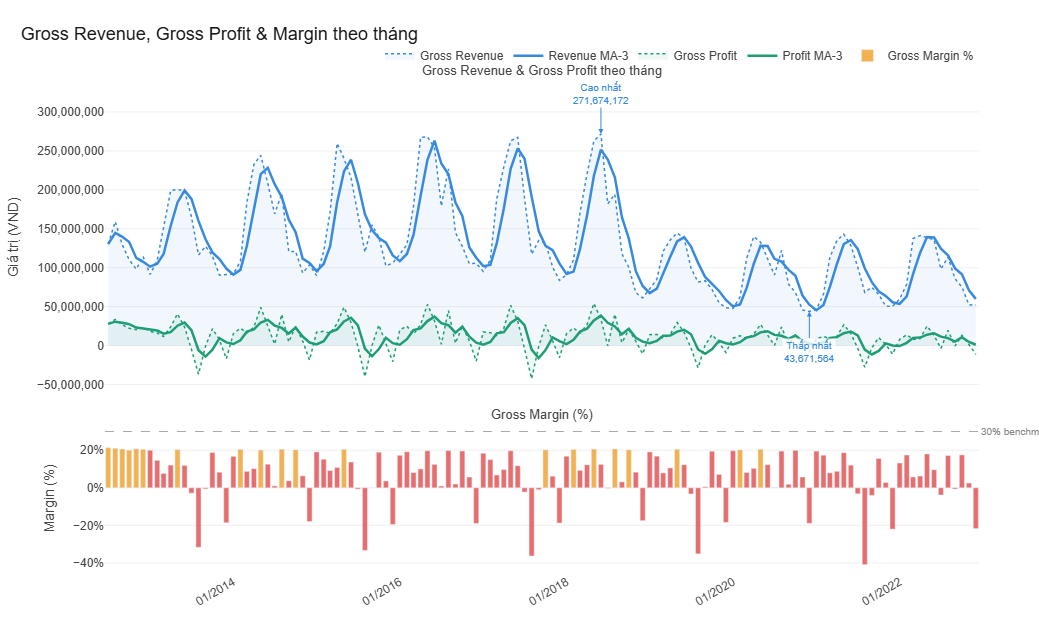

In [25]:
import plotly.io as pio
pio.renderers.default = "vscode"
fig.show()

In [26]:
"""
Chart: Revenue tăng trưởng YoY & MoM
======================================
Nguồn: order_items_master (output từ pipeline)
Yêu cầu: pip install pandas plotly
"""

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ──────────────────────────────────────────────
# 1. LOAD DỮ LIỆU
# ──────────────────────────────────────────────

df = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])
df = df.dropna(subset=["order_date", "gross_revenue"])
df["gross_revenue"] = pd.to_numeric(df["gross_revenue"], errors="coerce")

# ──────────────────────────────────────────────
# 2. CHUẨN BỊ DỮ LIỆU
# ──────────────────────────────────────────────

# ── 2a. Monthly (cho MoM) ─────────────────────
monthly = (
    df.groupby(df["order_date"].dt.to_period("M"))
    .agg(revenue=("gross_revenue", "sum"))
    .reset_index()
)
monthly["order_date"] = monthly["order_date"].dt.to_timestamp()
monthly = monthly.sort_values("order_date").reset_index(drop=True)

# MoM % = (tháng này - tháng trước) / tháng trước * 100
monthly["mom_pct"] = monthly["revenue"].pct_change() * 100
monthly["mom_abs"] = monthly["revenue"].diff()   # chênh lệch tuyệt đối

# Màu bar MoM: xanh nếu tăng, đỏ nếu giảm
monthly["mom_color"] = monthly["mom_pct"].apply(
    lambda x: "#1D9E75" if x >= 0 else "#E24B4A"
)

# ── 2b. Yearly (cho YoY) ──────────────────────
yearly = (
    df.groupby(df["order_date"].dt.year)
    .agg(revenue=("gross_revenue", "sum"))
    .reset_index()
    .rename(columns={"order_date": "year"})
    .sort_values("year")
    .reset_index(drop=True)
)

# YoY % = (năm này - năm trước) / năm trước * 100
yearly["yoy_pct"] = yearly["revenue"].pct_change() * 100
yearly["yoy_abs"] = yearly["revenue"].diff()

yearly["yoy_color"] = yearly["yoy_pct"].apply(
    lambda x: "#1D9E75" if x >= 0 else "#E24B4A"
)

# ── 2c. MoM theo từng năm riêng (heatmap data) ─
df["year"]  = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

pivot = (
    df.groupby(["year", "month"])["gross_revenue"]
    .sum()
    .reset_index()
    .pivot(index="year", columns="month", values="gross_revenue")
)
# YoY theo từng tháng: so tháng X năm N với tháng X năm N-1
pivot_yoy = pivot.pct_change(axis=0) * 100  # % thay đổi theo hàng (năm)

MONTH_NAMES = ["T1","T2","T3","T4","T5","T6","T7","T8","T9","T10","T11","T12"]

# ──────────────────────────────────────────────
# 3. VẼ BIỂU ĐỒ — 3 panel
# ──────────────────────────────────────────────

fig = make_subplots(
    rows=3, cols=1,
    row_heights=[0.35, 0.35, 0.30],
    vertical_spacing=0.08,
    subplot_titles=(
        "Tăng trưởng YoY (%) theo năm",
        "Tăng trưởng MoM (%) theo tháng",
        "Heatmap YoY (%) — từng tháng từng năm",
    )
)

# ── Panel 1: YoY bar + line revenue ──────────

# Bar revenue năm
fig.add_trace(go.Bar(
    x=yearly["year"].astype(str),
    y=yearly["revenue"],
    name="Revenue năm",
    marker_color="#378ADD",
    opacity=0.25,
    hovertemplate="Năm %{x}<br>Revenue: %{y:,.0f}<extra></extra>",
    yaxis="y1",
    showlegend=True,
), row=1, col=1)

# Bar YoY % (trục phụ)
fig.add_trace(go.Bar(
    x=yearly["year"].astype(str),
    y=yearly["yoy_pct"],
    name="YoY %",
    marker_color=yearly["yoy_color"],
    opacity=0.85,
    text=[f"{v:.1f}%" if pd.notna(v) else "" for v in yearly["yoy_pct"]],
    textposition="outside",
    textfont=dict(size=11),
    hovertemplate="Năm %{x}<br>YoY: %{y:.1f}%<extra></extra>",
    yaxis="y2",
    showlegend=True,
), row=1, col=1)

# Đường 0% baseline
fig.add_hline(
    y=0, row=1, col=1,
    line_color="#ccc", line_width=1,
)

# ── Panel 2: MoM bar + line revenue ──────────

# Line revenue tháng (nền mờ)
fig.add_trace(go.Scatter(
    x=monthly["order_date"],
    y=monthly["revenue"],
    name="Revenue tháng",
    mode="lines",
    line=dict(color="#378ADD", width=1.5),
    fill="tozeroy",
    fillcolor="rgba(55,138,221,0.06)",
    hovertemplate="%{x|%m/%Y}<br>Revenue: %{y:,.0f}<extra></extra>",
    yaxis="y3",
), row=2, col=1)

# Bar MoM %
fig.add_trace(go.Bar(
    x=monthly["order_date"],
    y=monthly["mom_pct"],
    name="MoM %",
    marker_color=monthly["mom_color"],
    opacity=0.8,
    hovertemplate=(
        "%{x|%m/%Y}<br>"
        "MoM: %{y:.1f}%<extra></extra>"
    ),
    yaxis="y4",
), row=2, col=1)

fig.add_hline(
    y=0, row=2, col=1,
    line_color="#ccc", line_width=1,
)

# ── Panel 3: Heatmap YoY theo tháng & năm ────

years  = [str(y) for y in pivot_yoy.index.tolist()]
months = [MONTH_NAMES[m - 1] for m in pivot_yoy.columns.tolist()]
z_vals = pivot_yoy.values.tolist()

# Custom text hiển thị trong ô
text_vals = [
    [f"{v:.1f}%" if pd.notna(v) else "N/A" for v in row]
    for row in pivot_yoy.values
]

fig.add_trace(go.Heatmap(
    z=z_vals,
    x=months,
    y=years,
    text=text_vals,
    texttemplate="%{text}",
    textfont=dict(size=10),
    colorscale=[
        [0.0,  "#E24B4A"],   # đỏ — giảm mạnh
        [0.45, "#FDECEA"],   # đỏ nhạt
        [0.5,  "#F5F5F5"],   # trắng — không đổi
        [0.55, "#E1F5EE"],   # xanh nhạt
        [1.0,  "#1D9E75"],   # xanh — tăng mạnh
    ],
    zmid=0,
    colorbar=dict(
        title=dict(text="YoY %", font=dict(size=11)),
        ticksuffix="%",
        thickness=12,
        len=0.28,
        y=0.10,
    ),
    hovertemplate="Năm %{y} — %{x}<br>YoY: %{text}<extra></extra>",
    showlegend=False,
), row=3, col=1)

# ──────────────────────────────────────────────
# 4. LAYOUT
# ──────────────────────────────────────────────

fig.update_layout(
    title=dict(
        text="Revenue — Tăng trưởng YoY & MoM",
        font=dict(size=18, color="#1a1a1a"),
        x=0.02,
    ),
    height=820,
    plot_bgcolor="#FFFFFF",
    paper_bgcolor="#FFFFFF",
    font=dict(family="Inter, sans-serif", size=12, color="#444"),
    hovermode="x unified",
    barmode="overlay",
    legend=dict(
        orientation="h", yanchor="bottom", y=1.01,
        xanchor="right", x=1,
        bgcolor="rgba(0,0,0,0)",
        font=dict(size=11),
    ),
    margin=dict(l=60, r=80, t=80, b=40),
)

# Trục panel 1 — dual axis
fig.update_yaxes(
    title_text="Revenue (VND)",
    gridcolor="#F0F0F0", zeroline=False,
    tickformat=",.0f",
    row=1, col=1,
)

# Trục panel 2
fig.update_yaxes(
    title_text="Revenue (VND)",
    gridcolor="#F0F0F0", zeroline=False,
    tickformat=",.0f",
    row=2, col=1,
)

# Trục panel 3
fig.update_yaxes(
    title_text="Năm",
    row=3, col=1,
    autorange="reversed",
)
fig.update_xaxes(
    title_text="Tháng",
    row=3, col=1,
)

fig.update_xaxes(showgrid=False, row=1, col=1)
fig.update_xaxes(showgrid=False, tickformat="%m/%Y", tickangle=-30, row=2, col=1)

for ann in fig.layout.annotations:
    ann.font.size = 13

# ──────────────────────────────────────────────
# 5. IN BẢNG TÓM TẮT
# ──────────────────────────────────────────────

print("\n===== TANG TRUONG YoY THEO NAM =====")
print(yearly[["year", "revenue", "yoy_pct", "yoy_abs"]]
      .rename(columns={
          "year":    "Nam",
          "revenue": "Revenue",
          "yoy_pct": "YoY (%)",
          "yoy_abs": "Chenh lech (VND)",
      })
      .to_string(index=False, float_format=lambda x: f"{x:,.1f}"))

print("\n===== TANG TRUONG MoM — TOP 5 TANG MANH NHAT =====")
top5_up = monthly.nlargest(5, "mom_pct")[["order_date", "revenue", "mom_pct"]]
print(top5_up.to_string(index=False, float_format=lambda x: f"{x:,.1f}"))

print("\n===== TANG TRUONG MoM — TOP 5 GIAM MANH NHAT =====")
top5_dn = monthly.nsmallest(5, "mom_pct")[["order_date", "revenue", "mom_pct"]]
print(top5_dn.to_string(index=False, float_format=lambda x: f"{x:,.1f}"))

# ──────────────────────────────────────────────
# 6. XUẤT & HIỂN THỊ
# ──────────────────────────────────────────────

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

html_path = output_dir / "chart_yoy_mom.html"
fig.write_html(str(html_path))
print(f"\nSaved: {html_path}")

try:
    png_path = output_dir / "chart_yoy_mom.png"
    fig.write_image(str(png_path), width=1200, height=820, scale=2)
    print(f"Saved: {png_path}")
except Exception:
    print("PNG skipped — cai kaleido: pip install kaleido")


C:\Users\quocb\AppData\Local\Temp\ipykernel_19312\838701313.py:17: DtypeWarning: Columns (5,6,23,24,26,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])



===== TANG TRUONG YoY THEO NAM =====
 Nam         Revenue  YoY (%)  Chenh lech (VND)
2012   741,497,748.0      NaN               NaN
2013 1,657,169,417.3    123.5     915,671,669.2
2014 1,871,845,882.8     13.0     214,676,465.5
2015 1,889,933,826.9      1.0      18,087,944.1
2016 2,104,640,677.5     11.4     214,706,850.6
2017 1,911,164,325.3     -9.2    -193,476,352.3
2018 1,850,122,456.1     -3.2     -61,041,869.2
2019 1,136,801,441.5    -38.6    -713,321,014.6
2020 1,054,512,158.8     -7.2     -82,289,282.7
2021 1,043,039,819.6     -1.1     -11,472,339.2
2022 1,169,748,831.7     12.1     126,709,012.1

===== TANG TRUONG MoM — TOP 5 TANG MANH NHAT =====
order_date       revenue  mom_pct
2020-03-01 111,804,374.2     79.0
2022-03-01 137,537,949.3     73.9
2021-03-01 113,274,006.6     71.4
2017-03-01 188,382,445.8     71.3
2014-03-01 183,513,882.1     69.2

===== TANG TRUONG MoM — TOP 5 GIAM MANH NHAT =====
order_date       revenue  mom_pct
2018-09-01 117,969,209.2    -39.3
2014-09-01

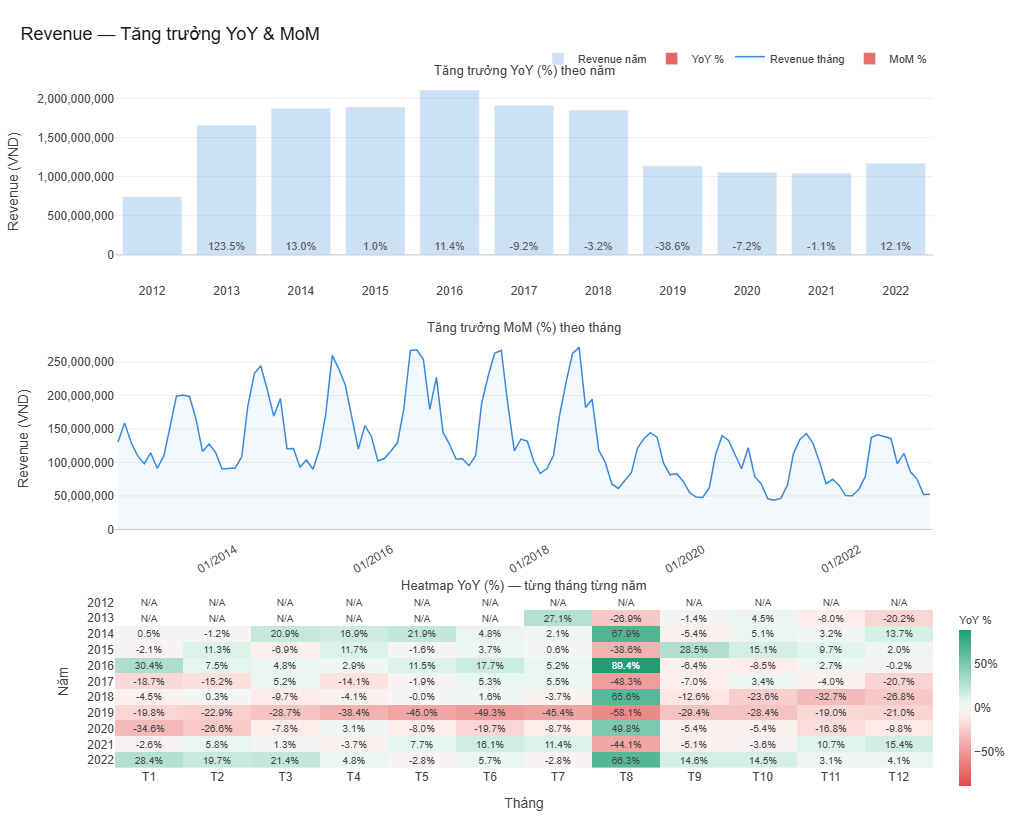

In [27]:
fig.show()

In [28]:
"""
Chart: Promotion ROI Analysis
==============================
Nguồn: order_items_master (output từ pipeline)
Yêu cầu: pip install pandas plotly
"""

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ──────────────────────────────────────────────
# 1. LOAD DỮ LIỆU
# ──────────────────────────────────────────────

df = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])
df["gross_revenue"]     = pd.to_numeric(df["gross_revenue"],     errors="coerce")
df["net_revenue"]       = pd.to_numeric(df["net_revenue"],       errors="coerce")
df["gross_profit"]      = pd.to_numeric(df["gross_profit"],      errors="coerce")
df["discount_amount"]   = pd.to_numeric(df["discount_amount"],   errors="coerce").fillna(0)
df["true_gross_margin"] = pd.to_numeric(df["true_gross_margin"], errors="coerce")
df["quantity"]          = pd.to_numeric(df["quantity"],          errors="coerce")

# ──────────────────────────────────────────────
# 2. CHUẨN BỊ DỮ LIỆU
# ──────────────────────────────────────────────

# ── 2a. Promo vs No-promo tổng quan ───────────
def promo_group(row):
    if row.get("has_promo", 0) == 0:
        return "Khong promo"
    return "Co promo"

df["promo_group"] = df.apply(promo_group, axis=1)

overview = df.groupby("promo_group").agg(
    so_don        =("order_id",          "nunique"),
    gross_revenue =("gross_revenue",     "sum"),
    net_revenue   =("net_revenue",       "sum"),
    gross_profit  =("gross_profit",      "sum"),
    discount_total=("discount_amount",   "sum"),
    avg_margin    =("true_gross_margin", "mean"),
    avg_quantity  =("quantity",          "mean"),
).reset_index()
overview["aov"]          = overview["net_revenue"] / overview["so_don"]
overview["discount_rate"]= overview["discount_total"] / overview["gross_revenue"] * 100

# ── 2b. ROI theo từng chiến dịch promo ────────
if "promo_name" in df.columns:
    by_promo = (
        df[df["has_promo"] == 1]
        .groupby("promo_name")
        .agg(
            so_don        =("order_id",          "nunique"),
            gross_revenue =("gross_revenue",     "sum"),
            net_revenue   =("net_revenue",       "sum"),
            gross_profit  =("gross_profit",      "sum"),
            discount_total=("discount_amount",   "sum"),
            avg_margin    =("true_gross_margin", "mean"),
        )
        .reset_index()
    )
    by_promo["aov"]           = by_promo["net_revenue"] / by_promo["so_don"]
    by_promo["discount_rate"] = by_promo["discount_total"] / by_promo["gross_revenue"] * 100
    # ROI = gross_profit / discount_total (mỗi đồng bỏ ra promo thu về bao nhiêu lợi nhuận)
    by_promo["roi"] = by_promo["gross_profit"] / by_promo["discount_total"].replace(0, float("nan"))
    by_promo = by_promo.sort_values("gross_profit", ascending=False).head(20)
else:
    by_promo = pd.DataFrame()

# ── 2c. ROI theo promo_type ───────────────────
if "promo_type" in df.columns:
    by_type = (
        df[df["has_promo"] == 1]
        .groupby("promo_type")
        .agg(
            so_don        =("order_id",          "nunique"),
            net_revenue   =("net_revenue",       "sum"),
            gross_profit  =("gross_profit",      "sum"),
            discount_total=("discount_amount",   "sum"),
            avg_margin    =("true_gross_margin", "mean"),
        )
        .reset_index()
    )
    by_type["roi"] = by_type["gross_profit"] / by_type["discount_total"].replace(0, float("nan"))
else:
    by_type = pd.DataFrame()

# ── 2d. Promo theo tháng ──────────────────────
monthly_promo = (
    df.groupby([df["order_date"].dt.to_period("M"), "promo_group"])
    .agg(
        net_revenue  =("net_revenue",       "sum"),
        gross_profit =("gross_profit",      "sum"),
        avg_margin   =("true_gross_margin", "mean"),
    )
    .reset_index()
)
monthly_promo["order_date"] = monthly_promo["order_date"].dt.to_timestamp()

promo_monthly   = monthly_promo[monthly_promo["promo_group"] == "Co promo"].sort_values("order_date")
nopromo_monthly = monthly_promo[monthly_promo["promo_group"] == "Khong promo"].sort_values("order_date")

# ── 2e. Promo theo category ───────────────────
if "category" in df.columns:
    by_cat = (
        df[df["has_promo"] == 1]
        .groupby("category")
        .agg(
            net_revenue   =("net_revenue",       "sum"),
            gross_profit  =("gross_profit",      "sum"),
            discount_total=("discount_amount",   "sum"),
            avg_margin    =("true_gross_margin", "mean"),
        )
        .reset_index()
    )
    by_cat["roi"] = by_cat["gross_profit"] / by_cat["discount_total"].replace(0, float("nan"))
    by_cat = by_cat.sort_values("roi", ascending=False)
else:
    by_cat = pd.DataFrame()

# ──────────────────────────────────────────────
# 3. VẼ BIỂU ĐỒ
# ──────────────────────────────────────────────

COLOR_PROMO   = "#378ADD"
COLOR_NOPROMO = "#AAAAAA"
COLOR_PROFIT  = "#1D9E75"
COLOR_LOSS    = "#E24B4A"
COLOR_ORANGE  = "#EF9F27"
BG            = "#FFFFFF"
GRID          = "#F0F0F0"
FONT          = "Inter, sans-serif"

fig = make_subplots(
    rows=3, cols=2,
    row_heights=[0.30, 0.38, 0.32],
    vertical_spacing=0.10,
    horizontal_spacing=0.10,
    subplot_titles=(
        "Promo vs No-Promo: Net Revenue & Gross Profit",
        "AOV & Discount Rate: Promo vs No-Promo",
        "Top 20 Chien Dich: Gross Profit & ROI",
        "True Gross Margin theo Promo Type",
        "Net Revenue theo thang: Promo vs No-Promo",
        "ROI theo Category (co promo)",
    )
)

# ── Chart 1: Promo vs No-promo Revenue & Profit ──
metrics   = ["Net Revenue", "Gross Profit"]
promo_row = overview[overview["promo_group"] == "Co promo"].iloc[0]   if len(overview[overview["promo_group"] == "Co promo"])   > 0 else None
nopromo_row = overview[overview["promo_group"] == "Khong promo"].iloc[0] if len(overview[overview["promo_group"] == "Khong promo"]) > 0 else None

for label, row, color in [
    ("Co promo",    promo_row,   COLOR_PROMO),
    ("Khong promo", nopromo_row, COLOR_NOPROMO),
]:
    if row is not None:
        fig.add_trace(go.Bar(
            x=metrics,
            y=[row["net_revenue"], row["gross_profit"]],
            name=label,
            marker_color=color,
            opacity=0.85,
            text=[f"{v/1e9:.1f}B" for v in [row["net_revenue"], row["gross_profit"]]],
            textposition="outside",
            hovertemplate=f"{label}<br>%{{x}}: %{{y:,.0f}}<extra></extra>",
        ), row=1, col=1)

# ── Chart 2: AOV & Discount Rate ──────────────
if promo_row is not None and nopromo_row is not None:
    groups = ["Co promo", "Khong promo"]
    aovs   = [promo_row["aov"], nopromo_row["aov"]]
    drates = [promo_row["discount_rate"], nopromo_row.get("discount_rate", 0)]
    colors = [COLOR_PROMO, COLOR_NOPROMO]

    fig.add_trace(go.Bar(
        x=groups, y=aovs,
        name="AOV",
        marker_color=colors,
        opacity=0.8,
        text=[f"{v:,.0f}" for v in aovs],
        textposition="outside",
        hovertemplate="%{x}<br>AOV: %{y:,.0f}<extra></extra>",
        showlegend=False,
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        x=groups, y=drates,
        name="Discount Rate %",
        mode="markers+text",
        marker=dict(color=COLOR_LOSS, size=14, symbol="diamond"),
        text=[f"{v:.1f}%" for v in drates],
        textposition="top center",
        yaxis="y6",
        hovertemplate="%{x}<br>Discount Rate: %{y:.1f}%<extra></extra>",
    ), row=1, col=2)

# ── Chart 3: Top chiến dịch theo Gross Profit & ROI ──
if not by_promo.empty:
    bar_colors = [COLOR_PROFIT if v >= 0 else COLOR_LOSS for v in by_promo["gross_profit"]]
    fig.add_trace(go.Bar(
        x=by_promo["promo_name"],
        y=by_promo["gross_profit"],
        name="Gross Profit",
        marker_color=bar_colors,
        opacity=0.8,
        hovertemplate="%{x}<br>Gross Profit: %{y:,.0f}<extra></extra>",
        showlegend=False,
    ), row=2, col=1)

    # ROI trên trục phụ
    roi_colors = [COLOR_PROFIT if v >= 1 else COLOR_LOSS for v in by_promo["roi"].fillna(0)]
    fig.add_trace(go.Scatter(
        x=by_promo["promo_name"],
        y=by_promo["roi"],
        name="ROI",
        mode="markers",
        marker=dict(color=roi_colors, size=9, symbol="circle"),
        hovertemplate="%{x}<br>ROI: %{y:.2f}x<extra></extra>",
    ), row=2, col=1)

    fig.add_hline(y=1, row=2, col=1,
                  line_dash="dash", line_color="#bbb", line_width=1,
                  annotation_text="ROI = 1x (hoa von)",
                  annotation_font=dict(size=9, color="#999"))

# ── Chart 4: Margin theo promo_type ───────────
if not by_type.empty:
    margin_colors = [
        COLOR_PROFIT if m >= 0.3 else COLOR_ORANGE if m >= 0.1 else COLOR_LOSS
        for m in by_type["avg_margin"].fillna(0)
    ]
    fig.add_trace(go.Bar(
        x=by_type["promo_type"],
        y=by_type["avg_margin"] * 100,
        name="Avg Margin %",
        marker_color=margin_colors,
        opacity=0.85,
        text=[f"{v*100:.1f}%" for v in by_type["avg_margin"].fillna(0)],
        textposition="outside",
        hovertemplate="%{x}<br>Avg Margin: %{y:.1f}%<extra></extra>",
        showlegend=False,
    ), row=2, col=2)

    fig.add_hline(y=30, row=2, col=2,
                  line_dash="dash", line_color="#bbb", line_width=1,
                  annotation_text="30% benchmark",
                  annotation_font=dict(size=9, color="#999"))

# ── Chart 5: Revenue theo tháng promo vs no-promo ──
fig.add_trace(go.Scatter(
    x=promo_monthly["order_date"], y=promo_monthly["net_revenue"],
    name="Co promo", mode="lines",
    line=dict(color=COLOR_PROMO, width=2),
    fill="tozeroy", fillcolor="rgba(55,138,221,0.07)",
    hovertemplate="%{x|%m/%Y}<br>Revenue: %{y:,.0f}<extra></extra>",
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=nopromo_monthly["order_date"], y=nopromo_monthly["net_revenue"],
    name="Khong promo", mode="lines",
    line=dict(color=COLOR_NOPROMO, width=2, dash="dot"),
    hovertemplate="%{x|%m/%Y}<br>Revenue: %{y:,.0f}<extra></extra>",
), row=3, col=1)

# ── Chart 6: ROI theo category ────────────────
if not by_cat.empty:
    cat_colors = [
        COLOR_PROFIT if v >= 2 else COLOR_ORANGE if v >= 1 else COLOR_LOSS
        for v in by_cat["roi"].fillna(0)
    ]
    fig.add_trace(go.Bar(
        x=by_cat["category"],
        y=by_cat["roi"],
        name="ROI theo category",
        marker_color=cat_colors,
        opacity=0.85,
        text=[f"{v:.1f}x" for v in by_cat["roi"].fillna(0)],
        textposition="outside",
        hovertemplate="%{x}<br>ROI: %{y:.2f}x<extra></extra>",
        showlegend=False,
    ), row=3, col=2)

    fig.add_hline(y=1, row=3, col=2,
                  line_dash="dash", line_color="#bbb", line_width=1,
                  annotation_text="ROI = 1x",
                  annotation_font=dict(size=9, color="#999"))

# ──────────────────────────────────────────────
# 4. LAYOUT
# ──────────────────────────────────────────────

fig.update_layout(
    title=dict(
        text="Promotion ROI Analysis",
        font=dict(size=18, color="#1a1a1a"),
        x=0.02,
    ),
    height=900,
    plot_bgcolor=BG,
    paper_bgcolor=BG,
    font=dict(family=FONT, size=11, color="#444"),
    hovermode="closest",
    barmode="group",
    legend=dict(
        orientation="h", yanchor="bottom", y=1.01,
        xanchor="right", x=1,
        bgcolor="rgba(0,0,0,0)",
        font=dict(size=11),
    ),
    margin=dict(l=50, r=50, t=80, b=50),
)

for ann in fig.layout.annotations:
    ann.font.size = 12

fig.update_yaxes(gridcolor=GRID, zeroline=False)
fig.update_xaxes(showgrid=False)

fig.update_xaxes(tickangle=-30, row=2, col=1)
fig.update_xaxes(tickangle=-15, row=3, col=1, tickformat="%m/%Y")

fig.update_yaxes(title_text="Gia tri (VND)", tickformat=",.0f", row=1, col=1)
fig.update_yaxes(title_text="AOV (VND)",     tickformat=",.0f", row=1, col=2)
fig.update_yaxes(title_text="Gross Profit",  tickformat=",.0f", row=2, col=1)
fig.update_yaxes(title_text="Margin (%)",    ticksuffix="%",    row=2, col=2)
fig.update_yaxes(title_text="Net Revenue",   tickformat=",.0f", row=3, col=1)
fig.update_yaxes(title_text="ROI (x)",       row=3, col=2)

# ──────────────────────────────────────────────
# 5. IN BẢNG TÓM TẮT
# ──────────────────────────────────────────────

print("\n===== PROMOTION ROI TONG QUAN =====")
print(overview[["promo_group","so_don","net_revenue","gross_profit",
                "discount_total","aov","avg_margin","discount_rate"]]
      .rename(columns={
          "promo_group":    "Nhom",
          "so_don":         "So don",
          "net_revenue":    "Net Revenue",
          "gross_profit":   "Gross Profit",
          "discount_total": "Tong giam gia",
          "aov":            "AOV",
          "avg_margin":     "Avg Margin",
          "discount_rate":  "Discount Rate %",
      }).to_string(index=False, float_format=lambda x: f"{x:,.1f}"))

if not by_promo.empty:
    print("\n===== TOP 10 CHIEN DICH HIEU QUA NHAT (GROSS PROFIT) =====")
    print(by_promo[["promo_name","so_don","net_revenue","gross_profit",
                    "discount_total","roi","avg_margin"]]
          .head(10)
          .rename(columns={
              "promo_name":    "Chien dich",
              "so_don":        "So don",
              "net_revenue":   "Net Revenue",
              "gross_profit":  "Gross Profit",
              "discount_total":"Tong giam gia",
              "roi":           "ROI (x)",
              "avg_margin":    "Avg Margin",
          }).to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

# ──────────────────────────────────────────────
# 6. XUẤT & HIỂN THỊ
# ──────────────────────────────────────────────



C:\Users\quocb\AppData\Local\Temp\ipykernel_19312\225241511.py:17: DtypeWarning: Columns (5,6,23,24,26,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])



===== PROMOTION ROI TONG QUAN =====
       Nhom  So don      Net Revenue    Gross Profit  Tong giam gia      AOV  Avg Margin  Discount Rate %
   Co promo  248242  4,685,830,212.5  -677,596,639.3  749,607,320.1 18,876.1        -0.1             13.8
Khong promo  398972 10,995,039,052.9 2,195,015,385.6            0.0 27,558.4         0.2              0.0

===== TOP 10 CHIEN DICH HIEU QUA NHAT (GROSS PROFIT) =====
        Chien dich  So don    Net Revenue  Gross Profit  Tong giam gia  ROI (x)  Avg Margin
  Fall Launch 2014    5064 102,386,562.04  2,530,603.38  11,376,285.26     0.22        0.02
  Fall Launch 2018    4049 103,549,647.81  2,031,416.62  11,505,517.14     0.18        0.03
  Fall Launch 2017    4969 116,135,214.62  1,944,308.36  12,908,025.34     0.15        0.02
  Fall Launch 2019    2873  72,746,607.20  1,603,420.32   8,082,956.82     0.20        0.02
  Fall Launch 2015    6872 137,516,810.07  1,385,017.87  15,286,980.12     0.09        0.02
  Fall Launch 2013    5632 117,26

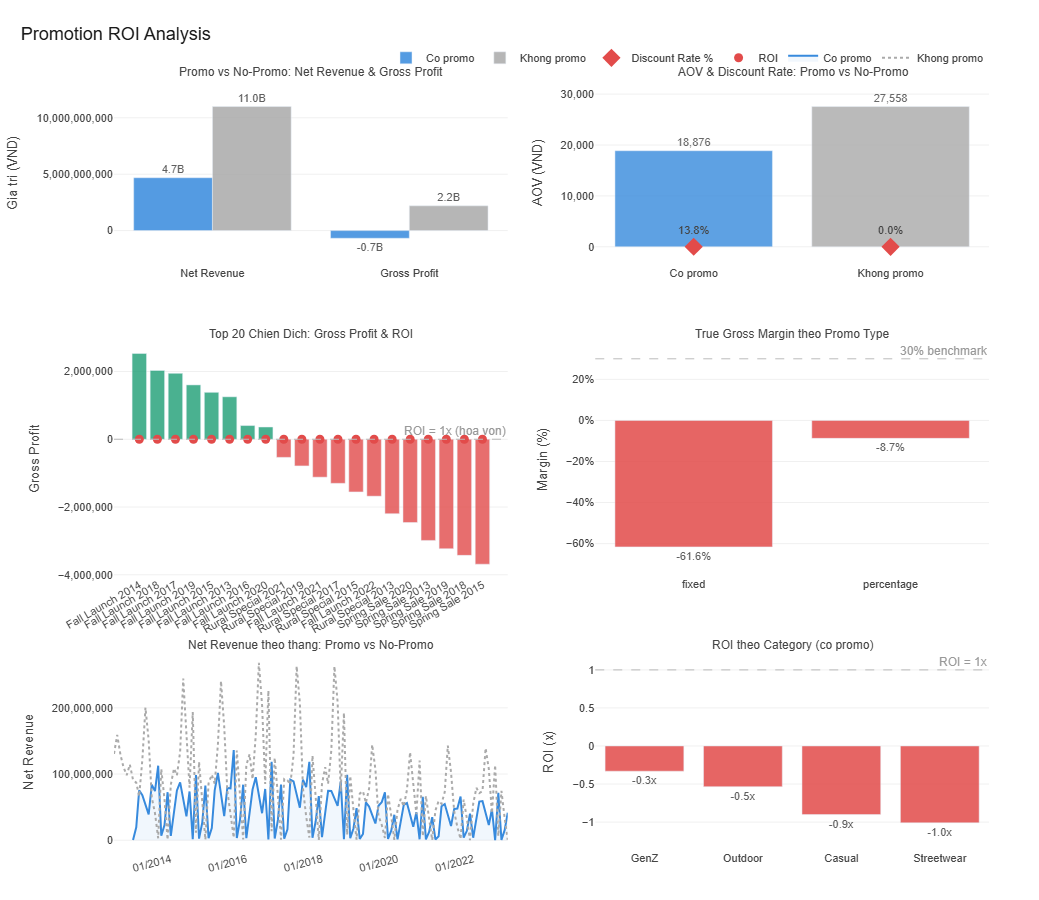

In [29]:
fig.show()